In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

import copy
import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v4 import NetLineStepProcessor

from torchvision.datasets import CIFAR100
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar100_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")


#### CIFAR100 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR100(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR100(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 128 #32 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 100 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [6]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_ADAM['test_loss'], color='g', alpha=.5, label='Adam')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Net-line')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_ADAM['test_accuracy'], color='g', alpha=.5, label='Adam')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Net-line')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same CNN architecture for different optimisers")

    plt.show()

#### Reference CNN

In [7]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 512),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(512, 100)
    )

    return model

In [8]:
#HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)
HISTORY_ADAM = collections.defaultdict(list)


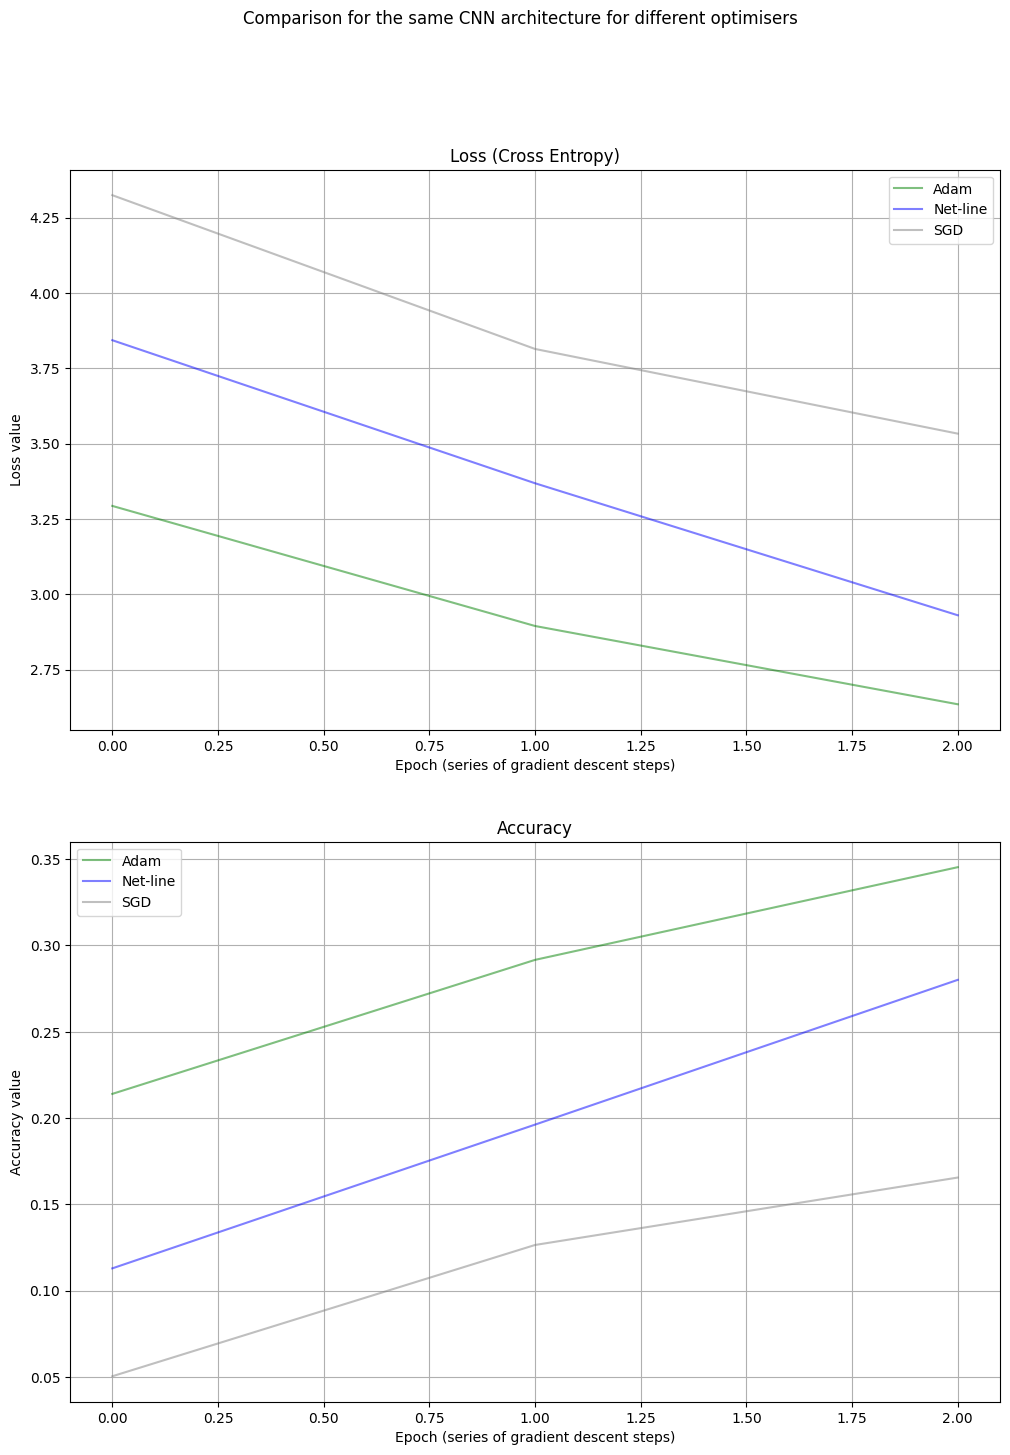

accuracy norm2=[0.11293512658227849, 0.1962025316455696, 0.2800632911392405], 
accuracy sgd-fix=[0.05043512658227848, 0.12648338607594936, 0.16554588607594936], 
accuracy adam-fix=[0.21400316455696203, 0.29163370253164556, 0.34533227848101267], 
switch=100, reducing_coeff=0.0078125


In [ ]:
def test_loop(testNet):
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    return test_loss_meter.avg, test_accuracy_meter.avg


NUM_EPOCH = 50
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

testAdam = copy.deepcopy(testOptfix)
loss_adam = nn.CrossEntropyLoss()
optimizerAdam = optim.Adam(testAdam.parameters())

do_dropout, epoch_switch=False, 100
for epoch in range(NUM_EPOCH):
    iter=0
    train_eta2raw_plus_meter, train_eta2raw_minus_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.000001:
        do_dropout = True
    epoch_switch = min(epoch, epoch_switch) if do_dropout else epoch_switch
    
    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.0125
    stepProcessor.eta_max = 1.0 #100* lr #if not do_dropout else lr
    stepProcessor.eta_min = 0.00000001 #* lr #if not do_dropout else lr
    stepProcessor.reducing_coeff = 1.0/BATCH_SIZE if not do_dropout else 1.0/(2.0*BATCH_SIZE) \
        if epoch < 10 else 1.0/(4.0*BATCH_SIZE) if epoch < 20 else 1.0/(8.0*BATCH_SIZE)
    stepProcessor.eta0 = 0.000_000_25
    stepProcessor.iter_max = 2
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0 #10.0
    
    stepProcessor.training_mode=do_dropout
    testNorm2S.train(False)
    step_params = {} #{"estimation_type": 'analytic-norm2'} #if not do_dropout \
        #else {"estimation_type": 'analytic-norm2', "check_additional": False, 'check_armiho': False}

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train()

    testAdam.train(True)

    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        train_eta2_meter.update(step_result.eta)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)
        if step_result.eta_raw > 0.0:
            train_eta2raw_plus_meter.update(step_result.eta_raw)
        else:
            train_eta2raw_minus_meter.update(step_result.eta_raw)  

        logging.info("####Step with SGD-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

        logging.info("####Step with Adam-fix, eta={}".format(optimizerAdam.param_groups[0]['lr']))
        logitsAdam = testAdam.forward(images)
        lossAdam = loss_adam(logitsAdam, labels)
        optimizerAdam.zero_grad()
        lossAdam.backward()
        optimizerAdam.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw_plus'].append(train_eta2raw_plus_meter.avg)
    HISTORY_NORM2['train_eta_raw_minus'].append(train_eta2raw_minus_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    testAdam.eval()
    # testing loop
    netl, neta = test_loop(testNorm2S)
    HISTORY_NORM2['test_loss'].append(netl)
    HISTORY_NORM2['test_accuracy'].append(neta) 

    sgdl, sgda = test_loop(testOptfix)
    HISTORY_OPTFIX['test_loss'].append(sgdl)
    HISTORY_OPTFIX['test_accuracy'].append(sgda)

    adaml, adama = test_loop(testAdam)
    HISTORY_ADAM['test_loss'].append(adaml)
    HISTORY_ADAM['test_accuracy'].append(adama)    
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM)
    print("accuracy norm2={}, \naccuracy sgd-fix={}, \naccuracy adam-fix={}, \nswitch={}, reducing_coeff={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], HISTORY_ADAM['test_accuracy']\
                  , epoch_switch, stepProcessor.reducing_coeff))


In [10]:
HISTORY_NORM2['train_armiho']


[0.751288875200321,
 0.7001954198692552,
 0.7268789982561321,
 0.7372818329329113,
 0.7289783788934854,
 0.705920616223868,
 0.67930786629754,
 0.6477571006737556,
 0.607210919837734,
 0.855732871367532,
 0.8539710444261479,
 0.8553072093036855,
 0.8544775130656067,
 0.8508248963870082,
 0.8501971121362727,
 0.8503387430528427,
 0.8539539672043124,
 0.85364764411555,
 0.8518267896095062,
 0.8542082478879266,
 0.8563550460146786,
 0.85337464026017,
 0.8541343260111126,
 0.854201534814441,
 0.8546269331056026,
 0.8570627789921295,
 0.8571200819615215,
 0.8556712771927626,
 0.8551884267775948,
 0.8593337910500619,
 0.8559741666845846,
 0.8587905033180074,
 0.858194421613028,
 0.8587875096351886,
 0.8620061602418599,
 0.8602958922656253,
 0.8594829532861582,
 0.8609563681501583,
 0.8654864953388821,
 0.8581061381343493,
 0.8633382712906865,
 0.8671140804711137,
 0.8644023910286754,
 0.8667576752051148,
 0.8694561226717944,
 0.862609309060247,
 0.8670598715884205,
 0.8695720879928053,
 0.86

In [11]:
HISTORY_NORM2['train_wolf']

[0.6124528181426532,
 0.468105672590183,
 0.5358176907646892,
 0.5646880072124898,
 0.5605669544177171,
 0.5357146515024739,
 0.5069441215254504,
 0.4711273718976395,
 0.43011536194761113,
 0.741829950852039,
 0.7392701737765178,
 0.7411255280549051,
 0.7396617164708151,
 0.7342015063019991,
 0.7339610425413915,
 0.734947421981404,
 0.740859938270002,
 0.7406009747863698,
 0.736422607642212,
 0.7409170888084232,
 0.7448360273825374,
 0.7408565883662653,
 0.7416044547226276,
 0.7408490267619299,
 0.7426001397883214,
 0.7461144111280298,
 0.7460539802537746,
 0.7434484171910963,
 0.7446436169385837,
 0.7498140325905545,
 0.7453139792223685,
 0.7484739701502032,
 0.7480559727428079,
 0.7485393976836853,
 0.7534555481048715,
 0.750934695018926,
 0.7511968122358373,
 0.7529576576946516,
 0.7598617008222018,
 0.748734216191127,
 0.7568596188200826,
 0.761812827989803,
 0.7580458268419153,
 0.7613584440647813,
 0.76606728767049,
 0.7558750353486098,
 0.7619014105948092,
 0.7662581462974386,
 

In [12]:
HISTORY_NORM2['train_eta']

[0.1787149044190422,
 0.018039950804948707,
 0.0220373463773321,
 0.024965475168367942,
 0.026560686706139557,
 0.02694231506654996,
 0.026746992725970396,
 0.02639880845406765,
 0.02546161019360822,
 0.020001439691987314,
 0.0192472276231907,
 0.01904684614982842,
 0.01865111104366856,
 0.018297567501707863,
 0.017761771968606524,
 0.017975403028628118,
 0.01801560999277193,
 0.018140819509231344,
 0.017449425371725235,
 0.017710633928031287,
 0.01769082614742166,
 0.017509345743175867,
 0.01713121896624918,
 0.01706105265284584,
 0.017032412186070312,
 0.01708118755046517,
 0.016856885004848724,
 0.01665394811666341,
 0.016729450965741778,
 0.016364604771570056,
 0.016429859164964648,
 0.016406034758593407,
 0.016111019619347033,
 0.015873064205644254,
 0.01593676945071142,
 0.01608718374765151,
 0.016035026194219714,
 0.016171153383359692,
 0.015858260653675554,
 0.015719516803492126,
 0.015802303084718455,
 0.01568391713221547,
 0.015403387718147442,
 0.015624852545972541,
 0.01570

In [15]:
HISTORY_NORM2['train_eta_raw_plus']

[0.18889972941185157,
 0.018039950804948707,
 0.0220373463773321,
 0.024965475168367942,
 0.026560686706139557,
 0.02694231506654996,
 0.026746992725970396,
 0.02639880845406765,
 0.02546161019360822,
 0.020001439691987314,
 0.0192472276231907,
 0.01904684614982842,
 0.01865111104366856,
 0.018297567501707863,
 0.017761771968606524,
 0.017975403028628118,
 0.01801560999277193,
 0.018140819509231344,
 0.017449425371725235,
 0.017710633928031287,
 0.01769082614742166,
 0.017509345743175867,
 0.01713121896624918,
 0.01706105265284584,
 0.017032412186070312,
 0.01708118755046517,
 0.016856885004848724,
 0.01665394811666341,
 0.016729450965741778,
 0.016364604771570056,
 0.016429859164964648,
 0.016406034758593407,
 0.016111019619347033,
 0.015873064205644254,
 0.01593676945071142,
 0.01608718374765151,
 0.016035026194219714,
 0.016171153383359692,
 0.015858260653675554,
 0.015719516803492126,
 0.015802303084718455,
 0.01568391713221547,
 0.015403387718147442,
 0.015624852545972541,
 0.0157